# Load data

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
# Load config
import sys
import os
import torch
import pickle
from pathlib import Path
import datajoint as dj
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

from model_in_the_loop.utils.hydra_utils import load_config,set_env_vars
cfg = load_config()
set_env_vars(cfg)  # set env variables for repo and data paths



home directory: /gpfs01/euler/User/ssuhai


In [5]:
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.dj_utils as dj_ut
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.rf_mei_test_tables as dj_tab
import thesis.code.validate_online_analysis.utils as val_ut
# import plotter
import thesis.code.plot.plot as plotter
plotter.set_default_params(kind='paper')

FIGURE_PATH = os.path.join(cfg.paths.repo_directory, 'thesis', 'figures', 'analysis_closed_loop_experiments', 'rf_mei_test')
os.makedirs(FIGURE_PATH, exist_ok=True)

print("importing dj_utils")
from thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.dj_utils import *
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.mei_utils as mei_ut
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.stats_utils as su
from model_in_the_loop.utils.model_training import get_dataloaders_and_data_info, get_predictions_targets_one_dataloader


from openretina.data_io.hoefling_2024.stimuli import movies_from_pickle


importing dj_utils


In [6]:
PATH_DATA = "/gpfs01/euler/data/Data/Suhai/thesis/other_data/FloDeja/20251008/1/mei_GCL4/GCL4_20251008_165030"
MOVIES_PATH = "/gpfs01/euler/User/ssuhai/openretina_cache/euler_lab/hoefling_2024/stimuli/rgc_natstim_18x16_joint_normalized_2024-01-11.pkl"
model_path = "model_full.pt"
ndd_path ="neuron_data_dict.pkl"
metadata_path = "metadata.pkl"


with open(os.path.join(PATH_DATA, ndd_path), 'rb') as f:
    neuron_data_dict = pickle.load(f)

movies_dict = movies_from_pickle(MOVIES_PATH)

refined_ensemble = torch.load(os.path.join(PATH_DATA, model_path),weights_only=False)

with open(os.path.join(PATH_DATA, metadata_path), 'rb') as f:
    metadata = pickle.load(f)


In [ ]:
dataloaders, data_info = get_dataloaders_and_data_info(cfg["model_configs"], neuron_data_dict, movies_dict)
all_preds, all_targets = get_predictions_targets_one_dataloader(refined_ensemble,
                                                                metadata["new_session_id"],
                                                                dataloaders["test"][metadata["new_session_id"]])


Creating movie dataloaders:   0%|          | 0/1 [00:00<?, ?it/s]

In [25]:
metadata.keys()

dict_keys(['roi2readout_idx_wmeis', 'roi_ids2readout_idx', 'neuron_idxs_passing_filter', 'neuron_testset_correls', 'new_session_id', 'scaled_means_before_centering', 'field_key'])

In [31]:

def plot_pred_actual(pred,
                     actual,
                     axes,
                     ylabel='Spike probability [a.u.]',
                     xlabel='Time [s]'):
    time = np.arange(len(pred)) / 30.0

    for i in range(pred.shape[1]):
        ax = axes.flatten()[i]
        ax.plot(time, pred[:,i], color = "orange", alpha=0.6)
        ax.plot(time, actual[:,i], color= "green", alpha=0.6)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        sns.despine(ax=ax)
    return axes

def reshape_actual(pred,actual):
    # reshape to (time, neurons)
    conv_eats_n_frames = actual.shape[0] - pred.shape[0]
    actual = actual[conv_eats_n_frames:,:]
    return actual



In [37]:
def plot_for_rois(roi_ids,
                  all_preds,
                  all_targets,
                  roi2readout_idx_wmeis
                  ):
    actual_reshaped = reshape_actual(all_preds,all_targets)
    readout_indices = [roi2readout_idx_wmeis[roi_id] for roi_id in roi_ids]
    preds_to_plot = all_preds[:,readout_indices]
    actuals_to_plot = actual_reshaped[:,readout_indices]
    fig,axes = plt.subplots(len(roi_ids),1,figsize=plotter.figsize_from_frac(1/3,1),sharey=True)
    axes = plot_pred_actual(preds_to_plot,actuals_to_plot,axes,ylabel="")
    return fig,axes



In [46]:
metadata["neuron_testset_correls"]

{'online_session_5_ventral1_20251008': {0: 0.2839946881066207,
  1: 0.12638879621864488,
  2: 0.31018137004623014,
  3: 0.1870678057202727,
  4: 0.4550306165589585,
  5: 0.7474970099779114,
  6: 0.4573955821439784,
  7: 0.6827318796117907,
  8: 0.7930505411765058,
  9: 0.24930954014067308,
  10: 0.26977213413009465,
  11: 0.16327038442585012,
  12: 0.3182055717115782,
  13: 0.6077876508532329,
  14: 0.15383434424869416,
  15: 0.6612036899814894,
  16: 0.6210462477743552,
  17: 0.5125785787323616,
  18: 0.33791921515398343,
  19: 0.2532185532621615,
  20: 0.6493594368447263,
  21: 0.9032848741500338,
  22: 0.6723997121992723,
  23: 0.08308487994928974,
  24: 0.7542475667549712}}

In [45]:
len(metadata["neuron_idxs_passing_filter"]) 

16

(<Figure size 300x900 with 7 Axes>,
 array([<Axes: xlabel='Time [s]'>, <Axes: xlabel='Time [s]'>,
        <Axes: xlabel='Time [s]'>, <Axes: xlabel='Time [s]'>,
        <Axes: xlabel='Time [s]'>, <Axes: xlabel='Time [s]'>,
        <Axes: xlabel='Time [s]'>], dtype=object))

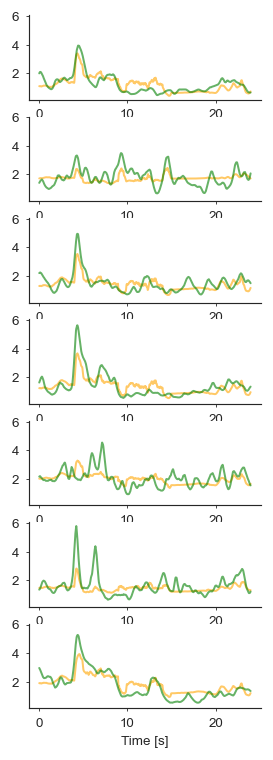

In [ ]:
plot_for_rois(
    roi_ids = [23,25,27,34,58,79,95],
    all_preds=all_preds,
    all_targets=all_targets,
    roi2readout_idx_wmeis=metadata["roi2readout_idx_wmeis"]
)

In [42]:
all_targets_reshaped = reshape_actual(all_preds,all_targets)

all_corrs = []
for col1,col2 in zip(all_targets_reshaped.T,all_preds.T):
    all_corrs.append(
        np.corrcoef(col1,col2)[0,1]
    )

print(f"Mean correl {np.mean(all_corrs)}, median {np.median(all_corrs)}")

print(f"Nr neurons {all_preds.shape[1]}")

Mean correl 0.4500744311476516, median 0.46177898931253086
Nr neurons 25
